## 1. Setup

In [ ]:
!pip install google-generativeai tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import google.generativeai as genai

genai.configure(api_key="GEMINI API KEY")
model = genai.GenerativeModel("gemini-2.5-flash")

try:
    response = model.generate_content("Hello Gemini!")
    print("✅ API key hoạt động bình thường!")
    print(response.text)
except Exception as e:
    print("❌ API key lỗi:", e)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ API key hoạt động bình thường!
Hello! How can I help you today?


In [ ]:
# PATHS
RAW_QAs = "/content/drive/MyDrive/Clinical LMM Project/Data Validation/tokenizeQA-validation/medreason_final_sft_dataset.json"                                             # Path to raw QAs dataset need to be validated
SOURCE_JSON_DIR = "/content/drive/MyDrive/Clinical LMM Project/Texts & Images Extraction/Hunter's Tropical Medicine and Emerging Infectious Diseases/book_extracted_json"  # Path to source files of Book Extracted JSON (generating the raw QAs dataset)
OUTPUT_DIR = "/content/drive/MyDrive/Clinical LMM Project/Data Validation/tokenizeQA-validation/Report"                                                                    # Path to output folder, where will save the validation report


In [ ]:
def load_source_json(filename):
    """Loads the specific chapter JSON required for validation."""
    path = os.path.join(SOURCE_JSON_DIR, filename)
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.dumps(json.load(f))
    except Exception as e:
        return None

## 2. Fidelity check

In [ ]:
import json
import time
import os
from getpass import getpass
import google.generativeai as genai
from typing import Dict, Any

# --- FIDELITY PROMPT ---
FIDELITY_PROMPT = """
You are a senior medical editor reviewing a diagnostic teaching case derived from
a historical medical source.

Your task is to decide whether the case is ACCEPTABLE for educational use.
This is a permissive, teaching-oriented fidelity review.

Your role is evaluative only.
Do NOT rewrite, correct, or improve the case.
ONLY flag clear violations.

=====================
INPUTS
=====================

1. SOURCE REPORT (Historical Ground Truth):
{source_json_content}

2. TEACHING CASE DRAFT:
- Vignette: "{question}"
- Final Diagnosis: "{answer}"
- Diagnostic Rationale: "{rationale}"

=====================
REVIEW PHILOSOPHY
=====================

Prioritize educational plausibility over strict textual matching.

The following are ACCEPTABLE and must NOT be flagged:
- Reasonable clinical inference not explicitly stated in the source
- Typical laboratory or imaging patterns mentioned illustratively
- General epidemiology or pathophysiology statements
- Implicit negatives if not contradicted
- Minor descriptive variation that does not alter diagnostic meaning
- Teaching-oriented explanations using general medical knowledge

=====================
FLAG ONLY IF
=====================

A case MUST be flagged only if it contains one or more of the following:

1. Direct contradiction of the source report
2. Biologically or epidemiologically impossible findings
3. Fabricated patient-specific facts that materially alter the diagnosis
4. Internal inconsistency (e.g., conflicting diagnoses)
5. Final diagnosis explicitly revealed in the vignette
6. Mutually exclusive or incompatible hallmark features combined


=====================
OUTPUT FORMAT (JSON ONLY)
=====================

Return ONLY a valid JSON object.

"flags":
- Use one or more of:
  - CASE_PROMPT_HALLUCINATION
  - DIAGNOSTIC_REASONING_HALLUCINATION
  - FINAL_DIAGNOSIS_IN_CASE_PROMPT
  - OTHER
- If no violations remain after the Global Knowledge Sanity Check:
  ["NONE"]

"editorcomments":
- One concise sentence per retained flag
- Omit or leave empty if flags = ["NONE"]
"""


In [ ]:
import os
import json
from tqdm import tqdm
def run_fidelity_check(qa_item):
    """
    Executes Judge 1 (Fidelity/Forensic Audit).
    Returns a dict with 'status': 'PASSED_FIDELITY' or 'REJECTED'.
    """

    # 1. Load the Ground Truth
    source_filename = qa_item.get("source_file")
    source_content = load_source_json(source_filename)

    if not source_content:
        # If we can't find the source, we can't audit, so we must error out.
        return {"status": "ERROR", "reason": f"Source file {source_filename} not found"}

    # 2. Prepare the Prompt
    fidelity_input = FIDELITY_PROMPT.format(
        source_json_content=source_content, # Truncate if too large
        question=qa_item["question"],
        answer=qa_item["answer_diagnosis"],
        rationale=qa_item["diagnostic_reasoning"]
    )

    # 3. Call the Model
    try:
        response_1 = model.generate_content(fidelity_input)
        text_resp = response_1.text.replace("```json", "").replace("```", "").strip()

        # Robust JSON extraction (finds the first { and last })
        if "{" in text_resp:
             text_resp = text_resp[text_resp.find("{"):text_resp.rfind("}")+1]

        fidelity_result = json.loads(text_resp)
    except Exception as e:
        return {"status": "ERROR", "reason": f"Fidelity API/Parse Error: {e}"}

    # 4. Analyze Flags
    # Valid "Pass" means flags is ["NONE"], "NONE", or empty list []
    flags = fidelity_result.get("flags", [])
    has_issues = False

    if isinstance(flags, list):
        # If list contains anything other than "NONE", it's a fail
        clean_flags = [f for f in flags if f != "NONE"]
        if len(clean_flags) > 0:
            has_issues = True
    elif isinstance(flags, str):
        if flags != "NONE":
            has_issues = True

    # 5. Return Verdict
    if has_issues:
        return {
            "status": "REJECTED",
            "reason": "Fidelity/Hallucination Issue",
            "flags": flags,
            "details": fidelity_result.get("editorcomments", {})
        }
    else:
        # SUCCESS CASE
        return {
            "status": "PASSED_FIDELITY",
            "reason": "No hallucinations found",
            "details": fidelity_result.get("editorcomments", {})
        }


In [ ]:
# ---------------------------------------------------------
# TEST BLOCK
# ---------------------------------------------------------
if __name__ == "__main__":
    # Your African Trypanosomiasis example
    test_item = {
      "source_file": "131_Echinococcosis_Hydatid_Disease.json",
      "think": "Key points: This case highlights the importance of considering neurocysticercosis in patients presenting with seizures, especially those from endemic regions. The diagnostic logic emphasizes the use of neuroimaging to identify characteristic lesions and serology to confirm the diagnosis.\nAnalytic distinctions: It distinguishes neurocysticercosis from other causes of seizures, such as tumors or vascular malformations, by focusing on the patient's origin, characteristic imaging findings, and serological confirmation.",
      "question": "A 35-year-old cis woman from a rural village in Peru presents to the clinic with a recent onset of focal seizures with secondary generalization. She reports no prior history of seizures but mentions experiencing occasional headaches over the past few months. Neurological examination is normal except for mild postictal confusion. Given her background and presentation, what is the most likely diagnosis?",
      "diagnostic_reasoning": "The patient's presentation with new-onset seizures, particularly focal seizures with secondary generalization, is a key indicator. Her origin from a rural village in Peru, an endemic region for neurocysticercosis, raises suspicion for this parasitic infection. Neuroimaging, such as CT or MRI, would be crucial to evaluate for the presence of cystic lesions in the brain parenchyma. Serological testing for cysticercosis antibodies in serum would help confirm the diagnosis. The combination of clinical presentation, epidemiological context, and diagnostic findings points towards neurocysticercosis.",
      "answer_diagnosis": "Neurocysticercosis"
    }

    print("🔎 Running Fidelity Check (Judge 1)...")
    result = run_fidelity_check(test_item)
    print(json.dumps(result, indent=2))

🔎 Running Fidelity Check (Judge 1)...
{
  "status": "PASSED_FIDELITY",
  "reason": "No hallucinations found",
  "details": ""
}


## 3. Quality check

In [ ]:
# --- QUALITY PROMPT ---
QUALITY_PROMPT = """
You are an expert medical educator tasked with evaluating a generated "Teaching Case" (Question/Answer pair) for its diagnostic-reasoning value.
Your goal is to ensure the case has the style and rigor of a diagnostic teaching case from a medical textbook.

### INPUTS TO EVALUATE
1. **CASE PRESENTATION (The Vignette):** "{question}"

2. **DIAGNOSTIC REASONING (The Rationale):** "{rationale}"

3. **FINAL DIAGNOSIS (The Answer):** "{answer}"

### EVALUATION RUBRIC
Apply the following 5 criteria strictly.

**1. THOROUGHNESS OF CASE PRESENTATION (Score 1-5)**
*Look for: HPI, past history, meds, allergies, vitals, focused exam, labs, imaging, timeline.*
* **1 (Seriously deficient):** Identifiers only; no vitals.
* **2 (Major gaps):** HPI + vitals OR exam, but not both.
* **3 (Adequate):** Present but sketchy details.
* **4 (Very good):** Complete data, clear timeline.
* **5 (Exemplary):** Serial data & course, high quality, rich clinical texture.

**2. EXPLICIT DIFFERENTIAL DIAGNOSIS (Yes / No)**
*Does the Rationale discuss >=2 plausible alternatives?*
* **Yes:** Mentions and rules out at least one other plausible disease.
* **No:** Only discusses the correct diagnosis.

**3. DEPENDENCE ON INTEGRATIVE CLINICAL REASONING (Score 1-5)**
*Measures need to combine >=2 data points (hx, labs, demographics, etc) to reach the Answer.*
* **1 (Trivial):** Lone clue gives answer (e.g., "Patient has Koplik spots" -> Measles).
* **2 (Minimal):** One dominant clue.
* **3 (Moderate):** Must merge TWO findings.
* **4 (High):** THREE+ clues; requires synthesis.
* **5 (Outstanding):** Stepwise, complex reasoning required.

**4. TRANSPARENCY OF DIAGNOSTIC REASONING PROCESS (Score 1-5)**
*Evaluate the 'Clinical Rationale' field.*
* **1 (None):** No rationale provided.
* **2 (Superficial):** Lists facts without the "why" or logic.
* **3 (Adequate):** Brief pivots or logical steps.
* **4 (Detailed):** Stepwise deduction, probabilistic thinking.
* **5 (Model):** Structured, addresses pitfalls, highly educational.

**5. STATED FINAL DIAGNOSIS (Yes / No)**
*Is the diagnosis clearly named in the 'Answer' field?*
* **Yes:** Specific disease named (e.g., "Vivax Malaria").
* **No:** Vague or missing (e.g., "A parasitic infection").

### OUTPUT FORMAT (JSON ONLY)
{{
  "scores": {{
    "thoroughness": (1-5),
    "explicit_differential": "Yes" or "No",
    "integrative_reasoning": (1-5),
    "transparency": (1-5),
    "stated_diagnosis": "Yes" or "No"
  }},
  "average_numeric_score": (Calculate the average of the three 1-5 scores),
  "critique": "Brief explanation of the reasoning behind these scores.",
  "status": "KEEP" (if Average Score >= 3 and Stated Diagnosis is Yes) or "DISCARD"
}}
"""

In [ ]:
import json
def run_quality_check(qa_item):
    """
    Runs the Quality Validation (Judge 2).
    Evaluates the pedagogical value of the QA pair.
    """

    # 1. Prepare Input (No Source File needed for this check)
    quality_input = QUALITY_PROMPT.format(
        question=qa_item["question"],
        answer=qa_item["answer_diagnosis"],
        rationale=qa_item["diagnostic_reasoning"]
    )

    # 2. Call the Model
    try:
        response = model.generate_content(quality_input)
        text_resp = response.text.replace("```json", "").replace("```", "").strip()

        # Robust JSON extraction
        if "{" in text_resp:
             text_resp = text_resp[text_resp.find("{"):text_resp.rfind("}")+1]

        quality_result = json.loads(text_resp)
    except Exception as e:
        return {"status": "ERROR", "reason": f"Quality API/Parse Error: {e}"}

    # 3. Determine Verdict based on LLM's "status" field
    # The Prompt calculates "KEEP" vs "DISCARD" based on the rubric
    final_status = quality_result.get("status", "DISCARD")

    if final_status == "KEEP":
        return {
            "status": "APPROVED",
            "scores": quality_result.get("scores", {}),
            "average_score": quality_result.get("average_numeric_score"),
            "critique": quality_result.get("critique")
        }
    else:
        return {
            "status": "REJECTED",
            "reason": f"Low Quality Score (Avg: {quality_result.get('average_numeric_score')})",
            "critique": quality_result.get("critique"),
            "scores": quality_result.get("scores", {})
        }



In [ ]:
# ---------------------------------------------------------
# TEST BLOCK
# ---------------------------------------------------------
if __name__ == "__main__":
    # Your African Trypanosomiasis example
    test_item = {
      "source_file": "131_Echinococcosis_Hydatid_Disease.json",
      "think": "Key points: This case highlights the importance of considering neurocysticercosis in patients presenting with seizures, especially those from endemic regions. The diagnostic logic emphasizes the use of neuroimaging to identify characteristic lesions and serology to confirm the diagnosis.\nAnalytic distinctions: It distinguishes neurocysticercosis from other causes of seizures, such as tumors or vascular malformations, by focusing on the patient's origin, characteristic imaging findings, and serological confirmation.",
      "question": "A 35-year-old cis woman from a rural village in Peru presents to the clinic with a recent onset of focal seizures with secondary generalization. She reports no prior history of seizures but mentions experiencing occasional headaches over the past few months. Neurological examination is normal except for mild postictal confusion. Given her background and presentation, what is the most likely diagnosis?",
      "diagnostic_reasoning": "The patient's presentation with new-onset seizures, particularly focal seizures with secondary generalization, is a key indicator. Her origin from a rural village in Peru, an endemic region for neurocysticercosis, raises suspicion for this parasitic infection. Neuroimaging, such as CT or MRI, would be crucial to evaluate for the presence of cystic lesions in the brain parenchyma. Serological testing for cysticercosis antibodies in serum would help confirm the diagnosis. The combination of clinical presentation, epidemiological context, and diagnostic findings points towards neurocysticercosis.",
      "answer_diagnosis": "Neurocysticercosis"
    }

    print("🔎 Running Quality Check (Judge 2)...")
    result = run_quality_check(test_item)
    print(json.dumps(result, indent=2))

🔎 Running Quality Check (Judge 2)...
{
  "status": "APPROVED",
  "scores": {
    "thoroughness": 2,
    "explicit_differential": "No",
    "integrative_reasoning": 4,
    "transparency": 4,
    "stated_diagnosis": "Yes"
  },
  "average_score": 3.33,
  "critique": "The case presentation is quite lean, lacking basic vitals, full past medical history, and medication/allergy information, which limits its thoroughness. A significant weakness is the complete absence of an explicit differential diagnosis in the rationale; it only focuses on the correct answer. This omission severely reduces its educational value for diagnostic reasoning. However, the case effectively requires the integration of seizure semiology with epidemiological data (new-onset focal seizures + endemic region) for diagnosis, demonstrating good integrative reasoning. The diagnostic reasoning for neurocysticercosis itself is transparent and logically connects the clinical features to the diagnosis, though it's constrained b

## 4. Final Evaluation

In [ ]:
import os
import json
import time
from tqdm import tqdm

VALID_OUTPUT = os.path.join(OUTPUT_DIR, f"Passed_Dataset.json")   # Output for passed items
REVIEW_OUTPUT = os.path.join(OUTPUT_DIR, f"Reviwed_Dataset.json")     # Output for failed items
REPORT_OUTPUT = os.path.join(OUTPUT_DIR, f"Validation_Report.json") # detailed log
BATCH_SIZE = 5                           # Save every 5 items

In [ ]:
# ==============================================================================
# HELPER FUNCTIONS
# ==============================================================================

def load_json_safe(filepath, default_value):
    """
    Safely loads a JSON file. Returns default_value if file doesn't exist
    or is corrupted.
    """
    if os.path.exists(filepath):
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                return json.load(f)
        except json.JSONDecodeError:
            print(f"⚠️ Warning: {filepath} exists but is corrupt. Starting fresh.")
            return default_value
    return default_value

def save_checkpoint(valid_list, review_list, report_list):
    """
    Saves the current progress to disk.
    """
    try:
        with open(VALID_OUTPUT, 'w', encoding='utf-8') as f:
            json.dump(valid_list, f, indent=2, ensure_ascii=False)

        with open(REVIEW_OUTPUT, 'w', encoding='utf-8') as f:
            json.dump(review_list, f, indent=2, ensure_ascii=False)

        with open(REPORT_OUTPUT, 'w', encoding='utf-8') as f:
            json.dump(report_list, f, indent=2, ensure_ascii=False)

        tqdm.write(f"💾 Checkpoint saved: {len(valid_list)} valid, {len(review_list)} review.")
    except Exception as e:
        tqdm.write(f"❌ Error saving checkpoint: {str(e)}")

In [ ]:
def main():
  if not os.path.exists(RAW_QAs):
      print(f"❌ Error: Raw QA file not found at {RAW_QAs}")
      return

  # 1. Load Input Data
  with open(RAW_QAs, 'r', encoding='utf-8') as f:
      all_qas = json.load(f)

  total_items = len(all_qas)

  # 2. Load Previous Progress (Resume Capability)
  passed_dataset = load_json_safe(VALID_OUTPUT, [])
  reviwed_dataset = load_json_safe(REVIEW_OUTPUT, [])
  full_report_log = load_json_safe(REPORT_OUTPUT, [])

  # Calculate where to resume
  processed_count = len(full_report_log)

  if processed_count > 0:
      print(f"🔄 Resuming validation. Already processed: {processed_count}/{total_items}")
      if processed_count >= total_items:
          print("✅ All items already processed!")
          return
      # Slice the input list to skip processed items
      remaining_qas = all_qas[processed_count:]
  else:
      print(f"🚀 Starting fresh validation pipeline for {total_items} items...")
      remaining_qas = all_qas

  # 3. Processing Loop
  for i, qa in enumerate(tqdm(remaining_qas, desc="Processing Batch")):

      # Calculate global index for logging purposes
      global_index = processed_count + i

      try:
          # --- Metadata for the Report ---
          qa_report_entry = {
              "index": global_index,
              "source_file": qa.get("source_file"),
              "question_snippet": qa.get("question", "")[:50] + "...",
              "fidelity_check": {},
              "quality_check": {},
              "final_decision": "PENDING"
          }

          #
          # 1. Fidelity Check (Source Match)
          fidelity_result = run_fidelity_check(qa)
          qa_report_entry["fidelity_check"] = fidelity_result

          # 2. Quality Check (LLM Judge)
          quality_result = run_quality_check(qa)
          qa_report_entry["quality_check"] = quality_result

          # Decision Gate
          is_fidelity_pass = fidelity_result.get("status") == "PASSED_FIDELITY"
          is_quality_pass = quality_result.get("status") == "APPROVED"

          if is_fidelity_pass and is_quality_pass:
              qa_report_entry["final_decision"] = "Valid QA"
              passed_dataset.append(qa)
          else:
              qa_report_entry["final_decision"] = "NEED_TO_BE_REVIEWD"
              reviwed_dataset.append(qa)

          # Add to full log
          full_report_log.append(qa_report_entry)

          # Rate Limit Sleep
          time.sleep(1.5)

      except Exception as e:
          # If a single item crashes, log it and CONTINUTE.
          tqdm.write(f"⚠️ Error processing item {global_index}: {e}")

          error_entry = {
              "index": global_index,
              "error": str(e),
              "final_decision": "ERROR_DURING_PROCESS"
          }
          full_report_log.append(error_entry)
          reviwed_dataset.append(qa) # Save to review to avoid data loss
          continue # <--- FIXED: Do not break the loop!

      # Save if we hit batch size OR if it's the very last item in the list
      items_processed_in_this_run = i + 1
      if items_processed_in_this_run % BATCH_SIZE == 0 or items_processed_in_this_run == len(remaining_qas):
          save_checkpoint(passed_dataset, reviwed_dataset, full_report_log)

if __name__ == "__main__":
  main()

  with open(RAW_QAs, 'r', encoding='utf-8') as f:
    all_qas = json.load(f)
  with open(VALID_OUTPUT, 'r', encoding='utf-8') as f:
    passed_dataset = json.load(f)
  with open(REVIEW_OUTPUT, 'r', encoding='utf-8') as f:
    reviewed_dataset = json.load(f)

  print("\n✅ VALIDATION COMPLETE.")
  print("\n" + "="*50)
  print(f"✅ RESULT")
  print(f"📥 Total Input:                 {len(all_qas)}")
  print(f"✅ Valid QAs Saved:             {len(passed_dataset)}")
  print(f"❌ Need to be reviewed QAs:     {len(reviewed_dataset)}")
  print("-" * 50)
  print(f"💾 Valid Data:  {VALID_OUTPUT}")
  print(f"📋 Full Report: {REPORT_OUTPUT}")
  print("="*50)

🔄 Resuming validation. Already processed: 429/429
✅ All items already processed!

✅ VALIDATION COMPLETE.

✅ RESULT
📥 Total Input:                 429
✅ Valid QAs Saved:             286
❌ Need to be reviewed QAs:     143
--------------------------------------------------
💾 Valid Data:  /content/drive/MyDrive/Clinical LMM Project/Data Validation/tokenizeQA-validation/Report/Passed_Dataset.json
📋 Full Report: /content/drive/MyDrive/Clinical LMM Project/Data Validation/tokenizeQA-validation/Report/Validation_Report.json


## Report Visualization

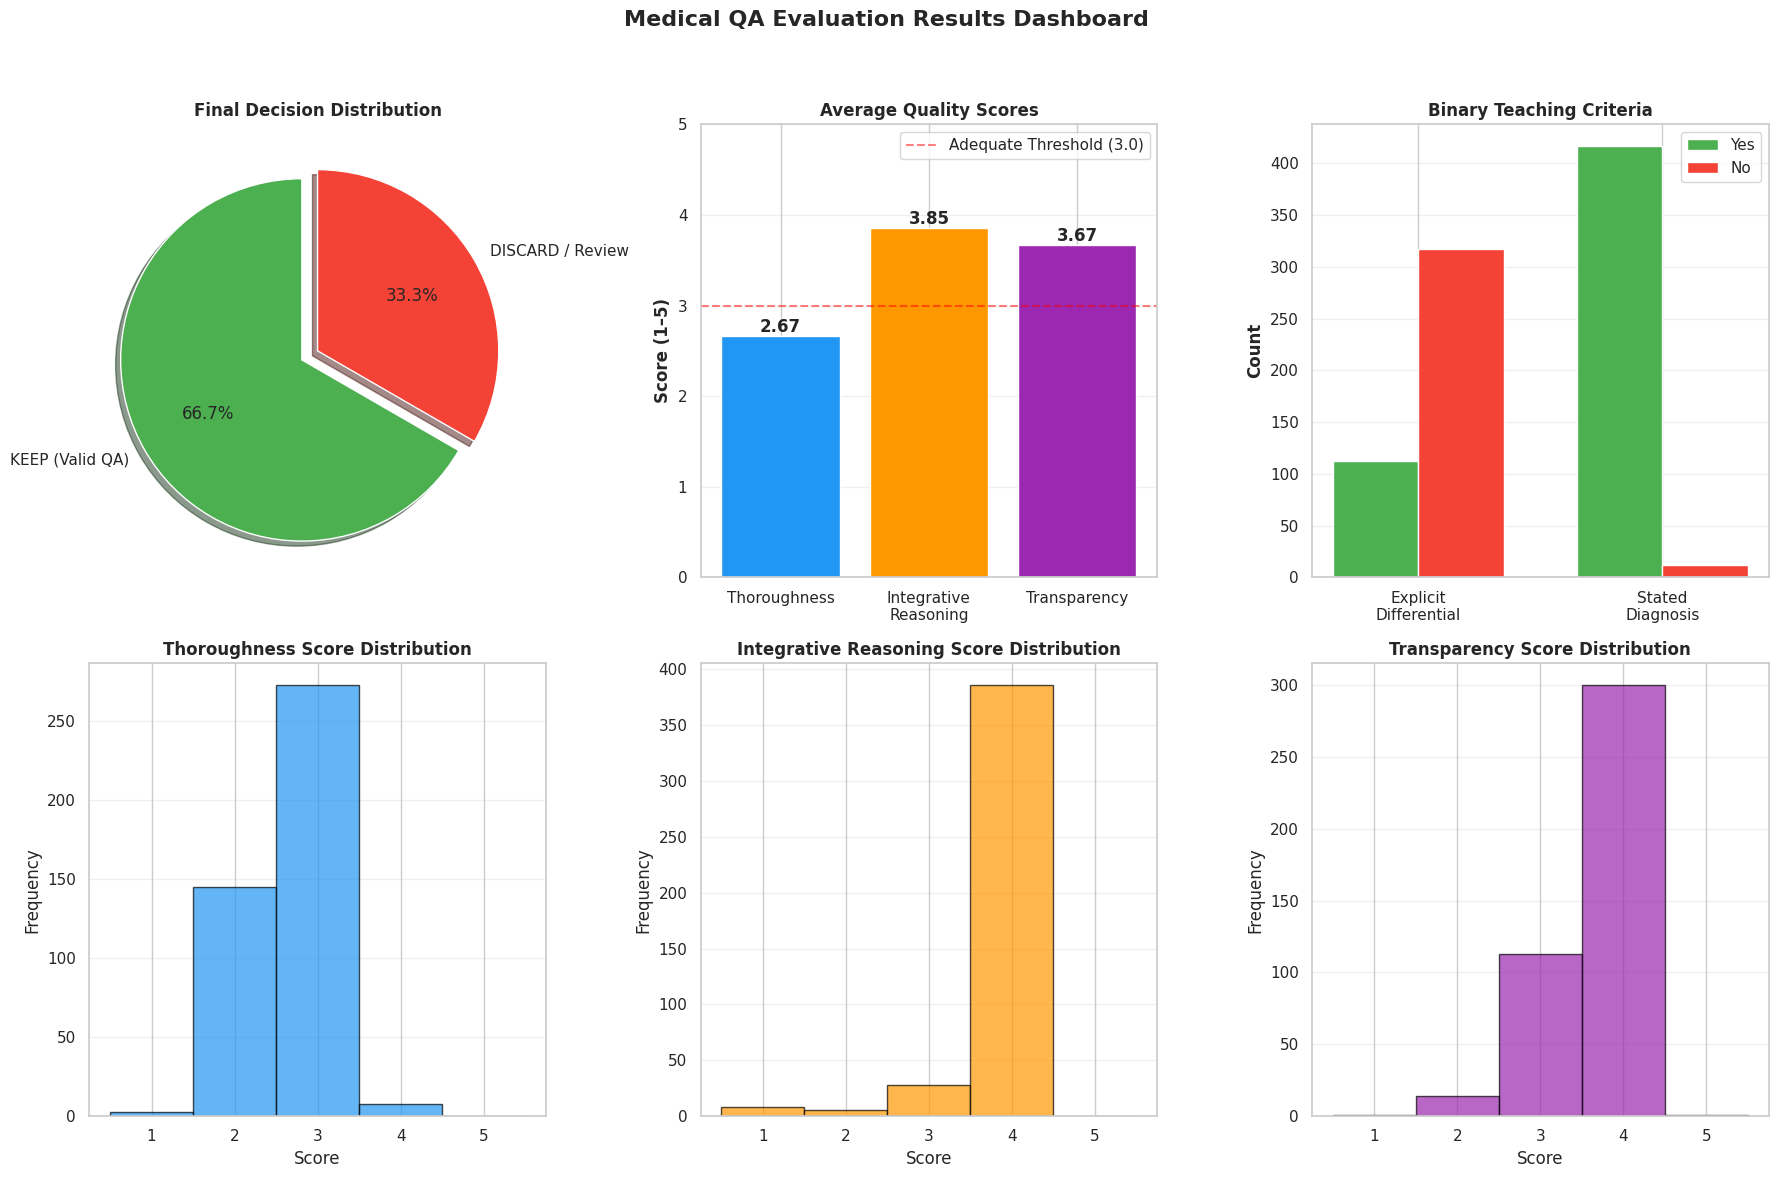

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load evaluation results
# =========================

OUTPUT_REPORT_FILE = "/content/drive/MyDrive/Clinical LMM Project/Data Validation/tokenizeQA-validation/Report/Validation_Report.json"

with open(OUTPUT_REPORT_FILE, 'r', encoding='utf-8') as f:
    evaluation_results = json.load(f)

# =========================
# Preprocess data
# =========================

# Final decision counts
final_decisions = [e.get("final_decision", "UNKNOWN") for e in evaluation_results]
keep_count = final_decisions.count("Valid QA")
discard_count = len(final_decisions) - keep_count

# Extract quality metrics safely
quality_metrics = [
    e.get("quality_check", {})
    for e in evaluation_results
    if e.get("quality_check", {}).get("scores") is not None
]

# Average numeric scores
def safe_mean(values):
    vals = [v for v in values if isinstance(v, (int, float))]
    return sum(vals) / len(vals) if vals else 0

avg_thoroughness = safe_mean(
    [m["scores"].get("thoroughness") for m in quality_metrics]
)

avg_integrative = safe_mean(
    [m["scores"].get("integrative_reasoning") for m in quality_metrics]
)

avg_transparency = safe_mean(
    [m["scores"].get("transparency") for m in quality_metrics]
)

# Binary criteria counts
differential_yes = sum(
    1 for m in quality_metrics
    if m["scores"].get("explicit_differential") == "Yes"
)

diagnosis_stated_yes = sum(
    1 for m in quality_metrics
    if m["scores"].get("stated_diagnosis") == "Yes"
)

# =========================
# Visualization
# =========================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Medical QA Evaluation Results Dashboard', fontsize=16, fontweight='bold')

# 1. KEEP vs DISCARD Pie Chart
ax1 = axes[0, 0]
labels = ['KEEP (Valid QA)', 'DISCARD / Review']
sizes = [keep_count, discard_count]
colors = ['#4CAF50', '#F44336']
explode = (0.1, 0)

ax1.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90
)
ax1.set_title('Final Decision Distribution', fontweight='bold')

# 2. Average Scores Bar Chart
ax2 = axes[0, 1]
metrics = ['Thoroughness', 'Integrative\nReasoning', 'Transparency']
scores = [avg_thoroughness, avg_integrative, avg_transparency]

bars = ax2.bar(metrics, scores, color=['#2196F3', '#FF9800', '#9C27B0'])
ax2.set_ylim(0, 5)
ax2.set_ylabel('Score (1–5)', fontweight='bold')
ax2.set_title('Average Quality Scores', fontweight='bold')
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.5, label='Adequate Threshold (3.0)')

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Binary Criteria (Yes/No)
ax3 = axes[0, 2]
criteria = ['Explicit\nDifferential', 'Stated\nDiagnosis']
yes_counts = [differential_yes, diagnosis_stated_yes]
no_counts = [
    len(quality_metrics) - differential_yes,
    len(quality_metrics) - diagnosis_stated_yes
]

x = np.arange(len(criteria))
width = 0.35

ax3.bar(x - width / 2, yes_counts, width, label='Yes', color='#4CAF50')
ax3.bar(x + width / 2, no_counts, width, label='No', color='#F44336')

ax3.set_ylabel('Count', fontweight='bold')
ax3.set_title('Binary Teaching Criteria', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(criteria)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Thoroughness Histogram
ax4 = axes[1, 0]
thoroughness_scores = [
    m["scores"].get("thoroughness", 0) for m in quality_metrics
]

ax4.hist(
    thoroughness_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#2196F3',
    edgecolor='black',
    alpha=0.7
)

ax4.set_title('Thoroughness Score Distribution', fontweight='bold')
ax4.set_xlabel('Score')
ax4.set_ylabel('Frequency')
ax4.set_xticks([1, 2, 3, 4, 5])
ax4.grid(axis='y', alpha=0.3)

# 5. Integrative Reasoning Histogram
ax5 = axes[1, 1]
integrative_scores = [
    m["scores"].get("integrative_reasoning", 0) for m in quality_metrics
]

ax5.hist(
    integrative_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#FF9800',
    edgecolor='black',
    alpha=0.7
)

ax5.set_title('Integrative Reasoning Score Distribution', fontweight='bold')
ax5.set_xlabel('Score')
ax5.set_ylabel('Frequency')
ax5.set_xticks([1, 2, 3, 4, 5])
ax5.grid(axis='y', alpha=0.3)

# 6. Transparency Histogram
ax6 = axes[1, 2]
transparency_scores = [
    m["scores"].get("transparency", 0) for m in quality_metrics
]

ax6.hist(
    transparency_scores,
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    color='#9C27B0',
    edgecolor='black',
    alpha=0.7
)

ax6.set_title('Transparency Score Distribution', fontweight='bold')
ax6.set_xlabel('Score')
ax6.set_ylabel('Frequency')
ax6.set_xticks([1, 2, 3, 4, 5])
ax6.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
